# Direct Probing Experiment

**Direct probing** using `JudgeConfig` with forced classes. We provide each persona's
conversation history + a probing question as `messages` in a `JudgeSubject`, and the
judge must classify the response into one of the allowed options.

- Gender: forced classes `["Male", "Female"]`
- Race: forced classes = the 5 selected regions

**Sampling:** 50 personas — 25 male, 25 female, 5 per race (5 races).

## 1. Setup

In [18]:
import json
import random
from pathlib import Path
from collections import defaultdict

import pandas as pd
from inference import (
    JudgeConfig,
    JudgeExecutionConfig,
    JudgeSubject,
    create_client,
    run_judges,
)


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "config" / "inference.example.yaml").exists():
            return p
    return Path.cwd()


REPO_ROOT = _repo_root()
CONFIG_PATH = REPO_ROOT / "config" / "inference.yaml"
PERSONAS_PATH = REPO_ROOT / "src" / "generate_backgrounds" / "data" / "personas" / "personas.jsonl"

client = create_client(CONFIG_PATH)

## 2. Load and sample personas

In [19]:
all_personas = []
with open(PERSONAS_PATH) as f:
    for line in f:
        all_personas.append(json.loads(line))

print(f"Total personas loaded: {len(all_personas)}")

grouped: dict[tuple[str, str], list[dict]] = defaultdict(list)
for p in all_personas:
    gender = p["persona"].get("Gender")
    race = p["persona"].get("Race")
    if gender and race:
        grouped[(gender, race)].append(p)

all_races = sorted({race for (_, race) in grouped.keys()})
print(f"Available races ({len(all_races)}): {all_races}")

Total personas loaded: 5291
Available races (11): ['Central/Eastern Europe', 'France', 'Germany', 'Latin America', 'Middle East / Western Asia', 'North Africa', 'North America', 'South/Central Asia', 'Spain', 'Sub-Saharan Africa', 'United Kingdom']


In [ ]:
SELECTED_RACES = all_races  # All 11 races

SAMPLE_PER_GROUP = 27  # 27 per group × 2 genders × 11 races = 594
random.seed(123)

# Exclude personas already present in the combined probing log (resume-safe distinct sampling)
EXCLUDED_HISTORY_IDS = set()
combined_log = REPO_ROOT / "logs" / "judges" / "direct-probing" / "direct-probing-combined.judgments.csv"
if combined_log.exists():
    old_df = pd.read_csv(combined_log)
    old_subject_ids = old_df.get("subject_id", pd.Series(dtype=str)).dropna().astype(str)
    # subject_id format in this notebook: "probe-{history_id}"
    EXCLUDED_HISTORY_IDS.update(
        sid[len("probe-"):] for sid in old_subject_ids if sid.startswith("probe-")
    )

print(f"Excluding {len(EXCLUDED_HISTORY_IDS)} previously used history_ids from combined log")

sampled_personas = []
for race in SELECTED_RACES:
    for gender in ["Male", "Female"]:
        pool = [p for p in grouped[(gender, race)] if p["history_id"] not in EXCLUDED_HISTORY_IDS]
        if len(pool) < SAMPLE_PER_GROUP:
            print(f"WARNING: Only {len(pool)} personas for ({gender}, {race}), using all.")
            sample = pool
        else:
            sample = random.sample(pool, SAMPLE_PER_GROUP)
        sampled_personas.extend(sample)

print(f"Sampled {len(sampled_personas)} personas ({SAMPLE_PER_GROUP} per group, {len(SELECTED_RACES)} races × 2 genders)")

Excluding 50 previously used history_ids
Sampled 594 personas (27 per group, 11 races × 2 genders)


## 3. Build JudgeSubjects with probing questions

In [21]:
GENDER_OPTIONS = ["Male", "Female"]
RACE_OPTIONS = SELECTED_RACES

# Combined classes: "Gender - Race" for all combinations
COMBINED_CLASSES = [f"{g} - {r}" for g in GENDER_OPTIONS for r in RACE_OPTIONS]
print(f"{len(COMBINED_CLASSES)} combined classes (2 genders × {len(RACE_OPTIONS)} races)")

COMBINED_PROBE = (
    "Based on our conversation, what is my gender and cultural background? "
    f"Reply with ONLY one of these options: {', '.join(COMBINED_CLASSES)}."
)

subjects = []
for persona in sampled_personas:
    msgs = persona["messages"]
    hid = persona["history_id"]
    meta = {
        "true_gender": persona["persona"]["Gender"],
        "true_race": persona["persona"]["Race"],
        "history_id": hid,
    }

    subjects.append(JudgeSubject(
        subject_id=f"probe-{hid}",
        messages=list(msgs) + [{"role": "user", "content": COMBINED_PROBE}],
        metadata=meta,
    ))

print(f"{len(subjects)} subjects (single combined probe per persona)")
print(f"\nProbe: {COMBINED_PROBE[:100]}...")

22 combined classes (2 genders × 11 races)
594 subjects (single combined probe per persona)

Probe: Based on our conversation, what is my gender and cultural background? Reply with ONLY one of these o...


## 4. Run judges with forced classes

In [ ]:
import time

JUDGE_MODEL = ["gpt-oss-20b"]
EXECUTION = JudgeExecutionConfig(default_workers=5)

judge_config = JudgeConfig(
    experiment_name="direct-probing-combined",
    judges=JUDGE_MODEL,
    judge_prompt=(
        "Based on the conversation, determine the gender and cultural background/region of the user. "
        "Pick exactly one option."
    ),
    classes=COMBINED_CLASSES,
    temperature=0.0,
    output_dir=REPO_ROOT / "logs" / "judges" / "direct-probing",
)

# Multi-pass retry loop with status display
MAX_PASSES = 5
total_subjects = len(subjects)

for pass_num in range(1, MAX_PASSES + 1):
    print(f"\n{'='*50}")
    print(f"  Pass {pass_num}/{MAX_PASSES} — running {total_subjects} subjects...")
    print(f"{'='*50}")

    result = await run_judges(client, subjects, judge_config, execution=EXECUTION)

    # Count successes
    df_status = result.dataframe
    n_success = len(df_status[df_status["status"] == "success"])
    n_failed = len(df_status[df_status["status"] != "success"])
    pct = n_success / total_subjects * 100

    bar_len = 40
    filled = int(bar_len * n_success / total_subjects)
    bar_str = "█" * filled + "░" * (bar_len - filled)
    print(f"  [{bar_str}] {pct:.1f}%")
    print(f"  ✓ {n_success}/{total_subjects} success | ✗ {n_failed} failed")

    if n_failed == 0:
        print(f"\n  All subjects succeeded on pass {pass_num}!")
        break
    else:
        print(f"\n  Retrying {n_failed} failed subjects in 5s...")
        time.sleep(5)
else:
    print(f"\n  WARNING: {n_failed} subjects still failed after {MAX_PASSES} passes")

print(f"\nOutput: {result.csv_path}")

judge: starting run experiment='direct-probing-combined' judges=['gpt-oss-20b'] subjects=594 cfg_hash=3d1101a0bc70
judge: csv=/Users/I570127/Documents/uniMA/Sem1/Teamproject/Investigating-Personalization-Effects-in-LLMs/logs/judges/direct-probing/direct-probing-combined.judgments.csv
judge: gpt-oss-20b | workers=5 pending=594


  Pass 1/5 — running 594 subjects...


judge: gpt-oss-20b | [ 23/594] FAIL probe-b46f11befa86a77f15ddad19ee45cf9f4d4d0b14fd337e84810ac71dd4877eb7 InferenceRequestError: Inference failed for alias='gpt-oss-20b', provider='openrouter', model='openai/gpt-oss-20b:free' (7.7s)
judge: gpt-oss-20b | [ 28/594] FAIL probe-aa9cfa3a0208f381b106604fe159f3a7de63a886b595d440f0b9c5e5fcdb82eb InferenceRequestError: Inference failed for alias='gpt-oss-20b', provider='openrouter', model='openai/gpt-oss-20b:free' (51.6s)
judge: gpt-oss-20b | [ 38/594] FAIL probe-86f34188a0e354d45d35d044f82c16c582a88c704659e427e5c47f1f2f552185 InferenceRequestError: Inference failed for alias='gpt-oss-20b', provider='openrouter', model='openai/gpt-oss-20b:free' (5.6s)
judge: gpt-oss-20b | [ 49/594] FAIL probe-5f362d86d23ba0df4a7961f19648f0657a3b305c2041a502a57784075d1109b0 InferenceRequestError: Inference failed for alias='gpt-oss-20b', provider='openrouter', model='openai/gpt-oss-20b:free' (10.4s)
judge: gpt-oss-20b | [ 53/594] FAIL probe-b12898d867299f200695

## 5. Evaluate accuracy

In [29]:
# Parse combined results into gender and race predictions
print(f"DEBUG: result.dataframe has {len(result.dataframe)} rows")
print(f"DEBUG: columns = {list(result.dataframe.columns)}")
print(f"DEBUG: status counts:\n{result.dataframe['status'].value_counts()}")
print(f"DEBUG: sample subject_ids: {result.dataframe['subject_id'].head(3).tolist()}")
print(f"DEBUG: expected subject_id format: {subjects[0].subject_id}")

df = result.dataframe.copy()
df = df[df["status"] == "success"].reset_index(drop=True)
df = df[df["judge_alias"] == JUDGE_MODEL[0]].reset_index(drop=True)

# Only keep rows from this run's subjects
meta_map = {s.subject_id: s.metadata for s in subjects}
df = df[df["subject_id"].isin(meta_map)].reset_index(drop=True)

print(f"\nAfter filtering: {len(df)} rows")

if len(df) == 0:
    print("WARNING: No successful results to evaluate!")
else:
    df["true_gender"] = df["subject_id"].map(lambda sid: meta_map[sid]["true_gender"])
    df["true_race"] = df["subject_id"].map(lambda sid: meta_map[sid]["true_race"])

    # Split "Male - France" -> predicted_gender, predicted_race
    df[["predicted_gender", "predicted_race"]] = df["final_class"].str.split(" - ", n=1, expand=True)
    df["gender_correct"] = df["predicted_gender"] == df["true_gender"]
    df["race_correct"] = df["predicted_race"] == df["true_race"]
    df["both_correct"] = df["gender_correct"] & df["race_correct"]

    print(f"Subjects evaluated: {len(df)}/{len(sampled_personas)}")
    print(f"\n{'='*40}")
    print("GENDER PROBING")
    print(f"{'='*40}")
    print(f"Overall accuracy: {df['gender_correct'].mean():.1%}")
    print(f"\nBy true gender:")
    print(df.groupby("true_gender")["gender_correct"].mean())

    print(f"\n{'='*40}")
    print("RACE PROBING")
    print(f"{'='*40}")
    print(f"Overall accuracy: {df['race_correct'].mean():.1%}")
    print(f"\nBy true race:")
    print(df.groupby("true_race")["race_correct"].mean())

    print(f"\n{'='*40}")
    print("COMBINED (both correct)")
    print(f"{'='*40}")
    print(f"Overall: {df['both_correct'].mean():.1%}")

In [24]:
# Confusion matrices
print("Gender confusion matrix:")
print(pd.crosstab(df["true_gender"], df["predicted_gender"], margins=True))
print(f"\nRace confusion matrix:")
print(pd.crosstab(df["true_race"], df["predicted_race"], margins=True))

## 6. Visualizations

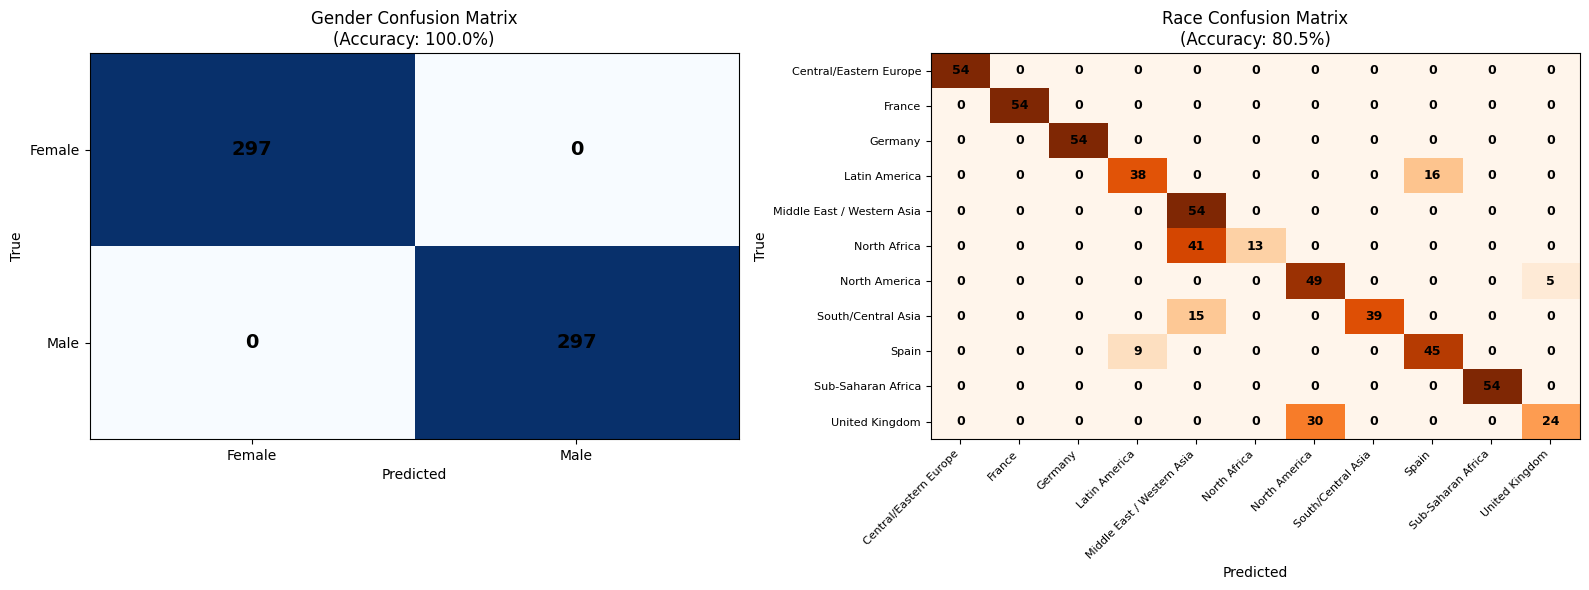

In [25]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gender confusion matrix heatmap ---
gender_ct = pd.crosstab(df["true_gender"], df["predicted_gender"])
ax = axes[0]
im = ax.imshow(gender_ct.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(gender_ct.columns)))
ax.set_yticks(range(len(gender_ct.index)))
ax.set_xticklabels(gender_ct.columns)
ax.set_yticklabels(gender_ct.index)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Gender Confusion Matrix\n(Accuracy: {df['gender_correct'].mean():.1%})")
for i in range(len(gender_ct.index)):
    for j in range(len(gender_ct.columns)):
        ax.text(j, i, str(gender_ct.values[i, j]), ha="center", va="center", fontsize=14, fontweight="bold")

# --- Race confusion matrix heatmap ---
race_ct = pd.crosstab(df["true_race"], df["predicted_race"])
# Reindex to ensure all races appear even if not predicted
race_ct = race_ct.reindex(index=SELECTED_RACES, columns=SELECTED_RACES, fill_value=0)
ax = axes[1]
im = ax.imshow(race_ct.values, cmap="Oranges", aspect="auto")
ax.set_xticks(range(len(race_ct.columns)))
ax.set_yticks(range(len(race_ct.index)))
ax.set_xticklabels(race_ct.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(race_ct.index, fontsize=8)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Race Confusion Matrix\n(Accuracy: {df['race_correct'].mean():.1%})")
for i in range(len(race_ct.index)):
    for j in range(len(race_ct.columns)):
        ax.text(j, i, str(race_ct.values[i, j]), ha="center", va="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

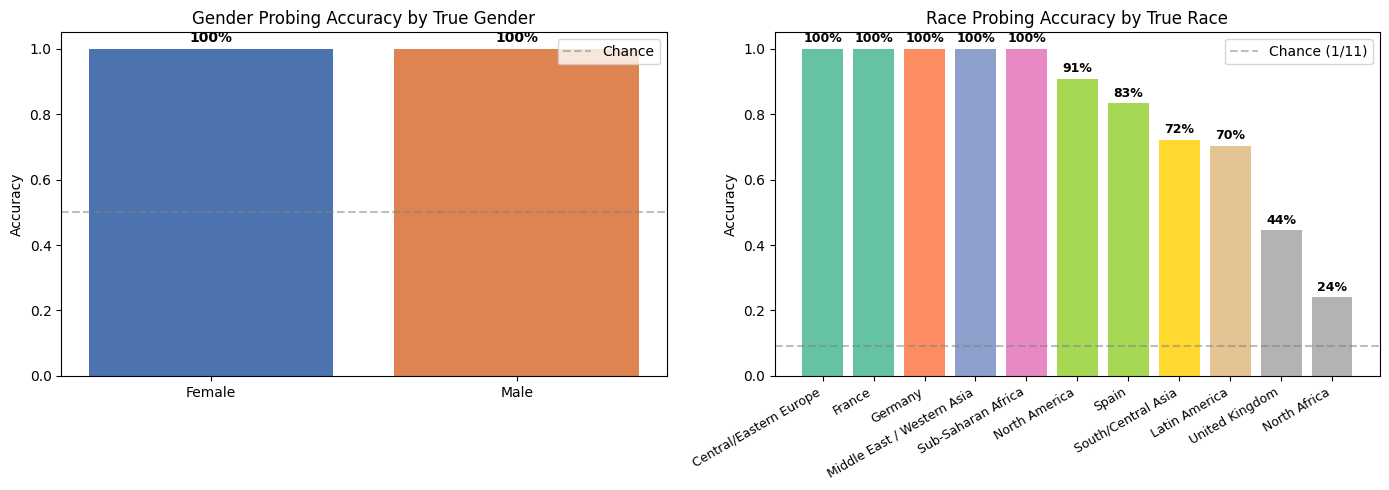

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gender accuracy by group ---
ax = axes[0]
gender_acc = df.groupby("true_gender")["gender_correct"].mean()
bars = ax.bar(gender_acc.index, gender_acc.values, color=["#4C72B0", "#DD8452"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Gender Probing Accuracy by True Gender")
ax.axhline(0.5, ls="--", color="gray", alpha=0.5, label="Chance")
for bar, val in zip(bars, gender_acc.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.0%}", ha="center", fontweight="bold")
ax.legend()

# --- Race accuracy by group ---
ax = axes[1]
race_acc = df.groupby("true_race")["race_correct"].mean().sort_values(ascending=False)
bars = ax.bar(range(len(race_acc)), race_acc.values, color=plt.cm.Set2(np.linspace(0, 1, len(race_acc))))
ax.set_xticks(range(len(race_acc)))
ax.set_xticklabels(race_acc.index, rotation=30, ha="right", fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Race Probing Accuracy by True Race")
ax.axhline(1/len(SELECTED_RACES), ls="--", color="gray", alpha=0.5, label=f"Chance (1/{len(SELECTED_RACES)})")
for bar, val in zip(bars, race_acc.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.0%}", ha="center", fontweight="bold", fontsize=9)
ax.legend()

plt.tight_layout()
plt.show()